In [1]:
import torch
from sparse_autoencoders import SparseAutoencoder, SparseAutoencoderTopK
import pandas as pd

In [2]:
input_dim = 2048
mult_factor = 8
hidden_dim = mult_factor * input_dim

root_dir = "models/"
#model_name = "sae_fr500pop_100epochs.pt"
#model_name = "sae_500epochs_500fr_sfe2_LRpatience5.pt"
#model_name = "sae_500epochs_10keu.pt"
#model_name = "sae_10keu_l26_500epochs.pt"
#model_name = "sae_10keu_l26_500epochs_leakyRelu.pt"
#model_name = "sae_10keu_l26_500epochs_topK.pt"
#model_name = "sae_10keu_l26_epochs500_dim1_sf01.pt"
model_name = "sae_fr_500_l35_dim16384_sf01_epochs411.pt"
#model_name = "sae_fr_500_noRegion_l35_dim16384_sf01_epochs212.pt"

model_name = root_dir + model_name

def load_model(model_name, intput_size, hidden_size):
    model = SparseAutoencoder(input_dim=intput_size,hidden_dim=hidden_size).to("cuda")
    #model = SparseAutoencoderTopK(input_dim=intput_size,hidden_dim=hidden_size,k=hidden_size).to("cuda")

    model.load_state_dict(
        torch.load(model_name)
    )

    model.eval()
    return model

model = load_model(model_name, input_dim, hidden_dim)


#data_name = "train_data/mlp_act_eu10k_l26.pkl"
data_name = "train_data/mlp_act_fr_500_l35.pkl"

df = pd.read_pickle(data_name)

from feature_helper import add_coords
DB_PATH = "../geocoding_pipeline/geonames.db"

df = add_coords(df, DB_PATH)

In [3]:
from feature_helper import inspect_neurons

# z = latent activations
activations_sums, z = inspect_neurons(model, df,hidden_dim=hidden_dim, mute=True)
print(z.shape)

100%|██████████| 16384/16384 [00:03<00:00, 4630.30it/s]

torch.Size([15340, 16384])


In [4]:
from feature_helper import check_if_spare

check_if_spare(z, threshold=0)

Avg active neurons: 250.747
Density: 0.015
Dead neurons: 0.984
Alive neurons: 0.016


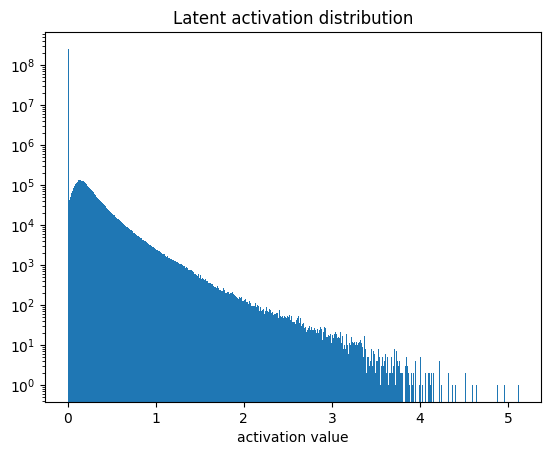

In [11]:
from feature_helper import plot_latent_distribution

plot_latent_distribution(z)

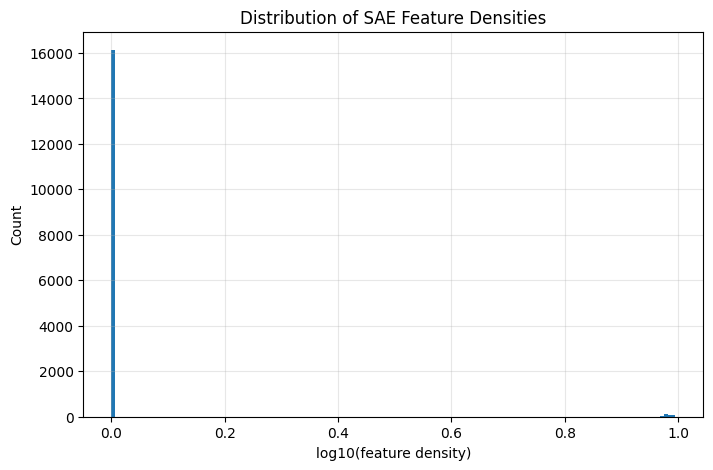

Features: 16384
Dead features: 16127
Mean density: 0.015304
Median density: 0.000000
Q. 0.5 = 0.000
Q. 0.9 = 0.000
Q. 0.95 = 0.000
Q. 0.99 = 0.980


In [12]:
from feature_helper import plot_feature_density_histogram

plot_feature_density_histogram(z, bins=150, use_log_densities=False, use_non_zero=False)

In [15]:
# neurones avec les plus grosses activation

torch.topk(torch.tensor(activations_sums), k=10)

/tmp/ipykernel_1296019/2471958923.py:3: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  torch.topk(torch.tensor(activations_sums), k=10)


torch.return_types.topk(
values=tensor([88.1075, 69.3904, 62.5620, 59.2692, 58.7740, 56.9073, 55.3155, 55.1270,
        50.7737, 46.0612]),
indices=tensor([ 1001, 14423,  8904, 15196, 13371,  1390, 13399, 13526, 11086,  2650]))

In [13]:
usage = (z > 0).float().mean(dim=0)
top_k = 10

top_vals, top_ids = torch.topk(usage, k=top_k)

for neuron_id, density in zip(top_ids.tolist(), top_vals.tolist()):
    print(f"Neuron {neuron_id}: density={density:.6f}")

Neuron 4927: density=0.994655
Neuron 1001: density=0.994329
Neuron 9002: density=0.994068
Neuron 13526: density=0.992568
Neuron 13399: density=0.992243
Neuron 15980: density=0.992047
Neuron 1917: density=0.991591
Neuron 6163: density=0.991460
Neuron 6158: density=0.991395
Neuron 1450: density=0.991330


In [6]:
active_mask = z > 0

strength = (
    z.sum(dim=0)
    / active_mask.sum(dim=0).clamp(min=1)
)

In [31]:
usage = (z > 0).float().mean(dim=0)
strength = z.max(dim=0).values

score = strength / (usage + 1e-6)

top_vals, top_ids = torch.topk(score, k=10)
for nid in top_ids.tolist():
    print(
        nid,
        f"density={usage[nid]:.6f}",
        f"max={strength[nid]:.4f}"
    )

7104 density=0.000137 max=0.0431
8133 density=0.000137 max=0.0401
11121 density=0.000137 max=0.0378
13959 density=0.000137 max=0.0360
14459 density=0.000137 max=0.0342
12579 density=0.000137 max=0.0313
16008 density=0.000137 max=0.0300
5741 density=0.000137 max=0.0295
15958 density=0.000137 max=0.0286
6025 density=0.000137 max=0.0282


In [13]:
interestingness = (
    z.max(dim=0).values
    * (1 - usage)
)

In [14]:
top_vals, top_ids = torch.topk(interestingness, k=10)
for nid in top_ids.tolist():
    print(
        nid,
        f"density={usage[nid]:.6f}",
        f"max={strength[nid]:.4f}"
    )

10539 density=0.482504 max=0.0575
5472 density=0.004237 max=0.0270
11200 density=0.731957 max=0.0329
13281 density=0.446555 max=0.0389
9815 density=0.699016 max=0.0275
6299 density=0.360990 max=0.0315
2738 density=0.523920 max=0.0487
14434 density=0.383133 max=0.0301
10413 density=0.619464 max=0.0422
14432 density=0.035539 max=0.0166


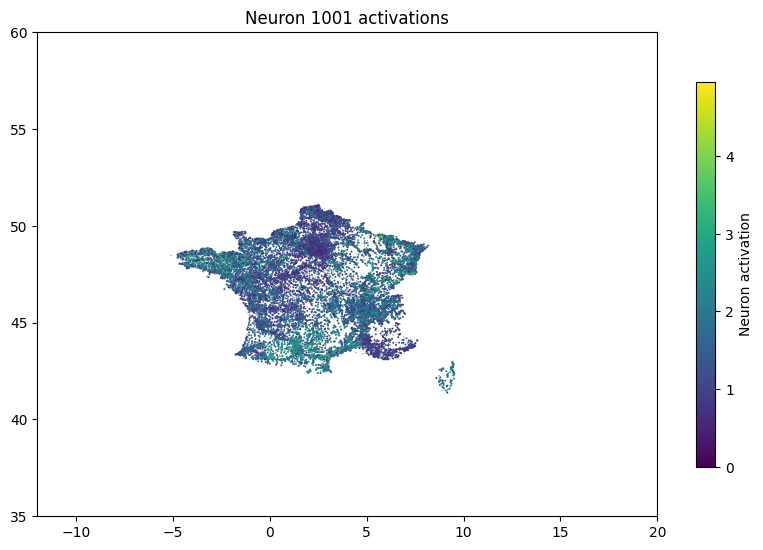

    === Neuron 1001 ===
top 1 -> 4.9605 : els Banys d'Arles, Occitanie
top 2 -> 4.8807 : Guimaëc, Brittany
top 3 -> 4.7013 : Uxeau, Bourgogne
top 4 -> 4.6397 : Coufouleux, Occitanie
top 5 -> 4.5893 : Plainoiseau, Bourgogne
top 6 -> 4.5260 : Albestroff, Grand Est
top 7 -> 4.5229 : Caurel, Grand Est
top 8 -> 4.4118 : Labaroche, Grand Est
top 9 -> 4.3668 : Avoudrey, Bourgogne
top 10 -> 4.3241 : Écouviez, Grand Est
top 11 -> 4.3229 : Lizio, Brittany
top 12 -> 4.2839 : Dompaire, Grand Est
top 13 -> 4.2419 : Francaltroff, Grand Est
top 14 -> 4.2288 : Torcé, Brittany
top 15 -> 4.2253 : Endoufielle, Occitanie
top 16 -> 4.2207 : Ruca, Brittany
top 17 -> 4.2202 : Seingbouse, Grand Est
top 18 -> 4.1553 : Baslieux, Grand Est
top 19 -> 4.1497 : Ancemont, Grand Est
top 20 -> 4.1359 : Le Russey, Bourgogne
top 21 -> 4.1270 : Parcé, Brittany
top 22 -> 4.1267 : Chalandry-Elaire, Grand Est
top 23 -> 4.1157 : Allenjoie, Bourgogne
top 24 -> 4.1115 : Devecey, Bourgogne
top 25 -> 4.1025 : Espère, Occitanie
t

In [16]:
from feature_helper import plot_neuron, print_topneurons_topk

NEURON_ID = 1001  

plot_neuron(df,z,neuron_id=NEURON_ID)
print_topneurons_topk(df, z, [NEURON_ID], top_k=50)

#create_html_neuron_map(df, z, NEURON_ID)